In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
data = pd.read_csv("../LevelAndSalaryData.csv")

In [3]:
data.head()

,Level,Salary
0,1,42000
1,2,44500
2,3,47200
3,4,50200
4,5,53500


In [4]:
data.corr()

,Level,Salary
Level,1.000000,0.972101
Salary,0.972101,1.000000


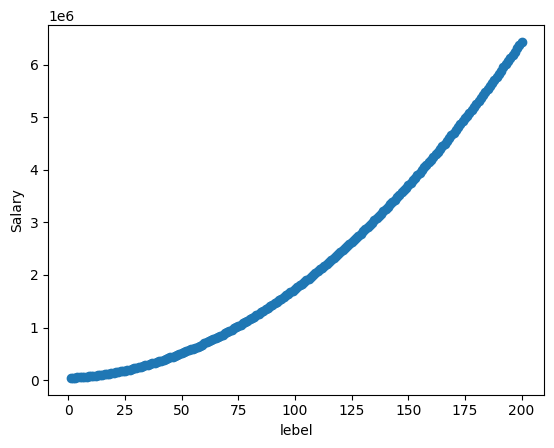

In [5]:
plt.scatter(data["Level"], data["Salary"])
plt.xlabel("lebel")
plt.ylabel("Salary")
plt.show()

In [6]:
X = data[["Level"]]
y = data[["Salary"]]


In [7]:
pf = PolynomialFeatures(degree=2)
pf.fit(X)
X = pf.transform(X)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2, test_size=0.2 )

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
# eqn- m1x1 + m2x2**2
lr.coef_

array([[   0.        , 1950.13065172,  149.99946278]])

In [11]:
lr.intercept_

array([39993.27366678])

In [12]:
lr.score(X_test, y_test)

0.9999999999978754

In [13]:
result = lr.predict(X)

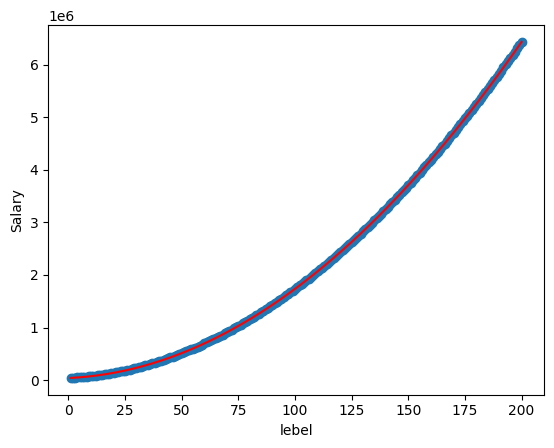

In [14]:
plt.scatter(data["Level"], data["Salary"])
plt.plot(data["Level"], result, c="red")
plt.xlabel("lebel")
plt.ylabel("Salary")
plt.show()